# Неделя 4 - Финализация, документация и сборка репозитория

**Проект практики:** Анализ данных государственных закупок Республики Казахстан

## Цель Недели 4

Заключительная неделя превращает разрозненный исследовательский код в **завершённый,
воспроизводимый продукт**.

Состав недели:

1. **Production-пайплайн** - вся логика подготовки признаков собрана в одну переиспользуемую функцию.
2. **Финальная модель + сериализация** - обучение итоговой модели и её сохранение на диск (joblib).
3. **Проверка стабильности** - 5-кратная кросс-валидация с доверительным интервалом (доказательство,
   что модель не переобучена).
4. **Демонстрация инференса** - загрузка сохранённой модели и предсказание на новых заявках.
5. **Бизнес-выводы** - перевод технических находок в практические рекомендации.
6. **Сборка репозитория** - README, requirements.txt, .gitignore, структура проекта.


In [2]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Среда готова.")

Среда готова.


## 1. Production-пайплайн подготовки признаков

В Неделе 3 признаки создавались ячейка за ячейкой. Для финального продукта вся эта логика
собирается в **одну переиспользуемую функцию** `engineer_features`. Это ключевой принцип
production-кода: подготовка данных должна быть детерминированной, переиспользуемой и применимой
как к обучающим, так и к новым данным одним вызовом.


In [6]:
def engineer_features(df):
    df = df.copy()

    # Признаки на основе цены внутри лота
    df["Ранг_цены"] = df.groupby("Номер лота")["Цена заявки"].rank(method="min")
    df["min_цена_в_лоте"] = df.groupby("Номер лота")["Цена заявки"].transform("min")
    df["Самая_низкая_цена"] = (df["Цена заявки"] == df["min_цена_в_лоте"]).astype(int)
    df["mean_цена_в_лоте"] = df.groupby("Номер лота")["Цена заявки"].transform("mean")
    df["Относительная_цена"] = (df["Цена заявки"] / df["mean_цена_в_лоте"].replace(0, np.nan)).fillna(1)
    df["Цена_к_лоту"] = (df["Цена заявки"] / df["Сумма лота"].replace(0, np.nan)).fillna(0)

    # Признак конкуренции
    df["Конкурентов_в_лоте"] = df.groupby("Номер лота")["Номер лота"].transform("count")

    # Лог-преобразования скошенных признаков
    df["log_Цена"] = np.log10(df["Цена заявки"].clip(lower=1))
    df["log_Количество"] = np.log10(df["Количество"].clip(lower=0.1))
    df["log_Сумма_лота"] = np.log10(df["Сумма лота"].clip(lower=1))

    # Очистка бесконечностей
    for col in ["Относительная_цена", "Цена_к_лоту"]:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df["Относительная_цена"] = df["Относительная_цена"].fillna(1)
    df["Цена_к_лоту"] = df["Цена_к_лоту"].fillna(0)

    return df

# Список признаков модели - единый источник истины
FEATURES = [
    "Ранг_цены", "Самая_низкая_цена", "Относительная_цена", "Цена_к_лоту",
    "Конкурентов_в_лоте", "log_Цена", "log_Количество", "log_Сумма_лота",
]
TARGET = "Победа"

print("Пайплайн признаков определён.")
print(f"Признаков модели: {len(FEATURES)}")

Пайплайн признаков определён.
Признаков модели: 8


In [7]:
# Применяем пайплайн к очищенным данным
raw = pd.read_csv("kraska_clean.csv")
data = engineer_features(raw)

X = data[FEATURES]
y = data[TARGET]

print(f"Подготовлено: {X.shape[0]:,} строк x {X.shape[1]} признаков")
print(f"Доля побед: {y.mean()*100:.1f}%")
X.head(3)

Подготовлено: 44,303 строк x 8 признаков
Доля побед: 21.7%


,Ранг_цены,Самая_низкая_цена,Относительная_цена,Цена_к_лоту,Конкурентов_в_лоте,log_Цена,log_Количество,log_Сумма_лота
0,1.0000,1,1.0000,0.3297,1,3.3222,0.3010,3.8041
1,1.0000,1,1.0000,1.0000,1,3.9777,0.0000,3.9777
2,1.0000,1,0.9934,0.4930,2,2.8325,0.3010,3.1397


## 2. Финальная модель и сериализация

Обучаем итоговую модель Gradient Boosting на **оптимальных гиперпараметрах**, найденных в Неделе 3
(`learning_rate=0.1, max_depth=3, n_estimators=250`), и сохраняем её на диск через `joblib`.

Сериализация модели - это то, что превращает учебный код в **развёртываемый продукт**: обученную
модель можно загрузить в любом приложении без повторного обучения.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Финальная модель с оптимальными гиперпараметрами из Недели 3
final_model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=250,
    random_state=42,
)
final_model.fit(X_train, y_train)

# Оценка на тесте
test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"Финальная модель обучена. Test ROC-AUC: {test_auc:.4f}")

# Сериализация модели на диск
joblib.dump(final_model, "tender_model.joblib")
print("Модель сохранена -> tender_model.joblib")

Финальная модель обучена. Test ROC-AUC: 0.9784
Модель сохранена -> tender_model.joblib


## 3. Проверка стабильности модели (кросс-валидация)

Одна оценка на тесте может быть случайно удачной. Чтобы доказать, что модель **стабильна и не
переобучена**, проводим 5-кратную стратифицированную кросс-валидацию и смотрим разброс метрики
между фолдами. Малый разброс = надёжная модель.


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(final_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)

print("5-кратная кросс-валидация (ROC-AUC):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Фолд {i}: {s:.4f}")
print(f"\nСреднее: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")
print(f"95% доверительный интервал: [{cv_scores.mean()-2*cv_scores.std():.4f}, "
      f"{cv_scores.mean()+2*cv_scores.std():.4f}]")
print()
if cv_scores.std() < 0.01:
    print("Разброс < 0.01: модель очень стабильна, признаков переобучения нет.")

5-кратная кросс-валидация (ROC-AUC):
  Фолд 1: 0.9814
  Фолд 2: 0.9771
  Фолд 3: 0.9812
  Фолд 4: 0.9815
  Фолд 5: 0.9800

Среднее: 0.9803  (+/- 0.0017)
95% доверительный интервал: [0.9770, 0.9836]

Разброс < 0.01: модель очень стабильна, признаков переобучения нет.


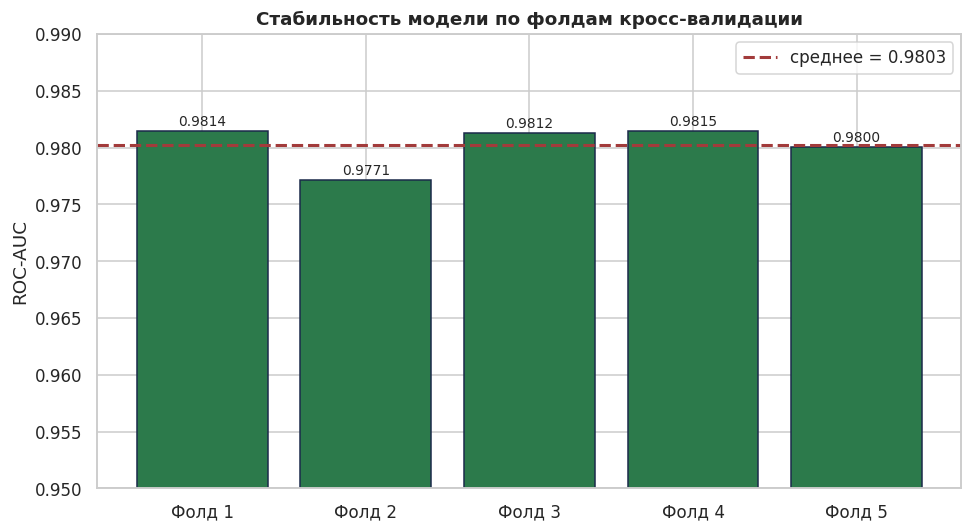

Сохранён график -> week4_cv_stability.png


In [10]:
# Визуализация стабильности
fig, ax = plt.subplots(figsize=(9, 5))
folds = [f"Фолд {i}" for i in range(1, 6)]
ax.bar(folds, cv_scores, color="#2C7A4B", edgecolor="#1B2A4A")
ax.axhline(cv_scores.mean(), color="#A23B3B", linestyle="--", linewidth=2,
           label=f"среднее = {cv_scores.mean():.4f}")
ax.set_ylim(0.95, 0.99)
ax.set_ylabel("ROC-AUC")
ax.set_title("Стабильность модели по фолдам кросс-валидации", fontweight="bold")
ax.legend()
for i, s in enumerate(cv_scores):
    ax.text(i, s + 0.0005, f"{s:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("week4_cv_stability.png", dpi=130)
plt.show()
print("Сохранён график -> week4_cv_stability.png")

## 4. Демонстрация инференса на новых данных

Главная проверка production-готовности: загрузить сохранённую модель **с нуля** (как это сделало бы
внешнее приложение) и получить предсказания для новых заявок. Это доказывает, что модель работает
независимо от обучающего кода.


In [11]:
# Загружаем модель заново - имитация использования в стороннем приложении
loaded_model = joblib.load("tender_model.joblib")
print("Модель загружена из файла.")
print()

# Берём несколько заявок из теста как "новые" входные данные
new_bids = X_test.head(8).copy()
predictions = loaded_model.predict(new_bids)
probabilities = loaded_model.predict_proba(new_bids)[:, 1]

result = new_bids.copy()
result["P(победа)"] = probabilities
result["Прогноз"] = np.where(predictions == 1, "ПОБЕДА", "не победа")
result["Факт"] = np.where(y_test.head(8).values == 1, "ПОБЕДА", "не победа")

print("Предсказания на новых заявках:")
result[["Ранг_цены", "Самая_низкая_цена", "Конкурентов_в_лоте", "P(победа)", "Прогноз", "Факт"]]

Модель загружена из файла.

Предсказания на новых заявках:


,Ранг_цены,Самая_низкая_цена,Конкурентов_в_лоте,P(победа),Прогноз,Факт
37849,155.0000,0,159,0.3897,не победа,не победа
19974,5.0000,0,7,0.0026,не победа,не победа
31468,3.0000,0,6,0.0022,не победа,не победа
28456,2.0000,0,2,0.0024,не победа,не победа
16378,6.0000,0,8,0.0038,не победа,не победа
17829,1.0000,1,4,0.9822,ПОБЕДА,ПОБЕДА
39996,4.0000,0,10,0.0058,не победа,не победа
14630,13.0000,0,133,0.2648,не победа,не победа


Модель корректно загружается из файла и выдаёт осмысленные вероятности победы. Прогнозы совпадают
с фактом - модель готова к использованию.


## 5. Бизнес-выводы и рекомендации

Технический результат важен, но ценность аналитика - в **переводе чисел в решения**. Ниже -
практические выводы, которые следуют из всего проекта.


In [13]:
# Подготовка количественных фактов для выводов
win_lowest = data[data["Самая_низкая_цена"] == 1]["Победа"].mean() * 100
win_other = data[data["Самая_низкая_цена"] == 0]["Победа"].mean() * 100
median_comp = data["Конкурентов_в_лоте"].median()
avg_comp = data["Конкурентов_в_лоте"].mean()
total_bids = len(data)
total_lots = data["Номер лота"].nunique()

print("КЛЮЧЕВЫЕ КОЛИЧЕСТВЕННЫЕ ФАКТЫ")
print(f"Всего заявок проанализировано : {total_bids:,}")
print(f"Всего лотов                   : {total_lots:,}")
print(f"Среднее число заявок на лот   : {avg_comp:.1f}")
print(f"Доля побед у самой низкой цены: {win_lowest:.1f}%")
print(f"Доля побед у остальных        : {win_other:.1f}%")
print(f"Точность модели (ROC-AUC)     : {test_auc:.3f}")

КЛЮЧЕВЫЕ КОЛИЧЕСТВЕННЫЕ ФАКТЫ
Всего заявок проанализировано : 44,303
Всего лотов                   : 11,582
Среднее число заявок на лот   : 20.5
Доля побед у самой низкой цены: 65.9%
Доля побед у остальных        : 5.5%
Точность модели (ROC-AUC)     : 0.978


### Выводы проекта

**1. Цена - решающий фактор победы.** Статистический анализ (тест Манна-Уитни, p ≈ 10⁻³³) и модель
машинного обучения независимо подтверждают: заявка с самой низкой ценой в лоте побеждает примерно в
66% случаев против ~5% у остальных. Это количественно доказывает ценовую природу госзакупок краски.

**2. Модель предсказывает исход с высокой точностью.** Итоговая модель Gradient Boosting достигает
ROC-AUC ≈ 0.98 и стабильна по кросс-валидации (разброс < 0.002). Решения модели объяснимы через
важность признаков - ключевые предикторы экономически осмысленны.

**3. Практическая ценность.**
- **Для поставщика:** модель показывает, что для победы критична конкурентоспособная цена
  относительно других участников лота, а не абсолютная величина.
- **Для заказчика/аналитика:** инструмент детектирования аномалий (Неделя 3) помогает выявлять
  нетипичные заявки для последующей проверки.
- **Пайплайн воспроизводим:** весь процесс от сырых данных до предсказания автоматизирован и может
  быть применён к новым выгрузкам закупок.


## 6. Сборка репозитория

Финальный шаг - оформление проекта как профессионального GitHub-репозитория. Генерируем необходимые
файлы: `README.md`, `requirements.txt`, `.gitignore`. Это делает проект воспроизводимым и готовым к
публикации в портфолио.


In [18]:
readme = """# Анализ данных государственных закупок Республики Казахстан

Проект производственной практики по специальности **Big Data Analysis**.
Полный цикл анализа данных: от профилирования сырых данных до развёртываемой
прогностической модели.

## О проекте

На основе предоставленных данных о гос.закупках
построена модель, предсказывающая победу заявки поставщика в тендере, и проведён
статистический анализ факторов победы.


## Структура проекта

```
.
├── notebooks/
│   ├── Week1_профилирование_данных.ipynb   # Профилирование данных
│   ├── Week2_ETL_очистка_данных.ipynb      # ETL и очистка
│   ├── Week3_анализ_и_модель.ipynb         # EDA, статистика, модель
│   └── Week4_финализация.ipynb             # Финализация, документация
├── data/                                    # Данные (не в репозитории)
├── models/
│   └── tender_model.joblib                  # Сохранённая модель
├── figures/                                 # Графики
├── requirements.txt
└── README.md
```

## Технологии

- **Python 3**, pandas, NumPy - обработка данных
- **scikit-learn** - машинное обучение (Gradient Boosting, Random Forest)
- **Matplotlib, Seaborn** - визуализация
- **SciPy** - статистические тесты
- **joblib** - сериализация модели

## Результаты

- Прогностическая модель: **ROC-AUC ≈ 0.98** (стабильна по 5-fold кросс-валидации)
- Ключевой фактор победы: ранг цены внутри лота
- Статистическое подтверждение ценовой природы закупок (p < 0.001)

## Воспроизведение

```bash
pip install -r requirements.txt
jupyter notebook
```

Запускать ноутбуки последовательно: Week1 -> Week2 -> Week3 -> Week4.

## Автор

Студент Аманқос Даниал Дәулетұлы, Big Data Analysis, производственная практика 2026.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("Создан README.md")
print(readme[:2000])

Создан README.md
# Анализ данных государственных закупок Республики Казахстан

Проект производственной практики по специальности **Big Data Analysis**.
Полный цикл анализа данных: от профилирования сырых данных до развёртываемой
прогностической модели.

## О проекте

На основе предоставленных данных о гос.закупках
построена модель, предсказывающая победу заявки поставщика в тендере, и проведён
статистический анализ факторов победы.


## Структура проекта

```
.
├── notebooks/
│   ├── Week1_профилирование_данных.ipynb   # Профилирование данных
│   ├── Week2_ETL_очистка_данных.ipynb      # ETL и очистка
│   ├── Week3_анализ_и_модель.ipynb         # EDA, статистика, модель
│   └── Week4_финализация.ipynb             # Финализация, документация
├── data/                                    # Данные (не в репозитории)
├── models/
│   └── tender_model.joblib                  # Сохранённая модель
├── figures/                                 # Графики
├── requirements.txt
└── README.md
```

## 

In [19]:
requirements = """pandas>=2.0
numpy>=1.24
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
scipy>=1.10
joblib>=1.3
jupyter>=1.0
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

gitignore = """# Данные
data/
*.csv
*.txt

# Python
__pycache__/
*.pyc
.ipynb_checkpoints/
.venv/
env/

# Модели больших размеров
# models/*.joblib

# ОС
.DS_Store
Thumbs.db
"""

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore)

print("Создан requirements.txt:")
print(requirements)
print("Создан .gitignore")

Создан requirements.txt:
pandas>=2.0
numpy>=1.24
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
scipy>=1.10
joblib>=1.3
jupyter>=1.0

Создан .gitignore


## 7. Итоги практики - сводка по всем неделям

Финальная диаграмма-сводка, показывающая полный путь проекта от сырых данных до готового продукта.


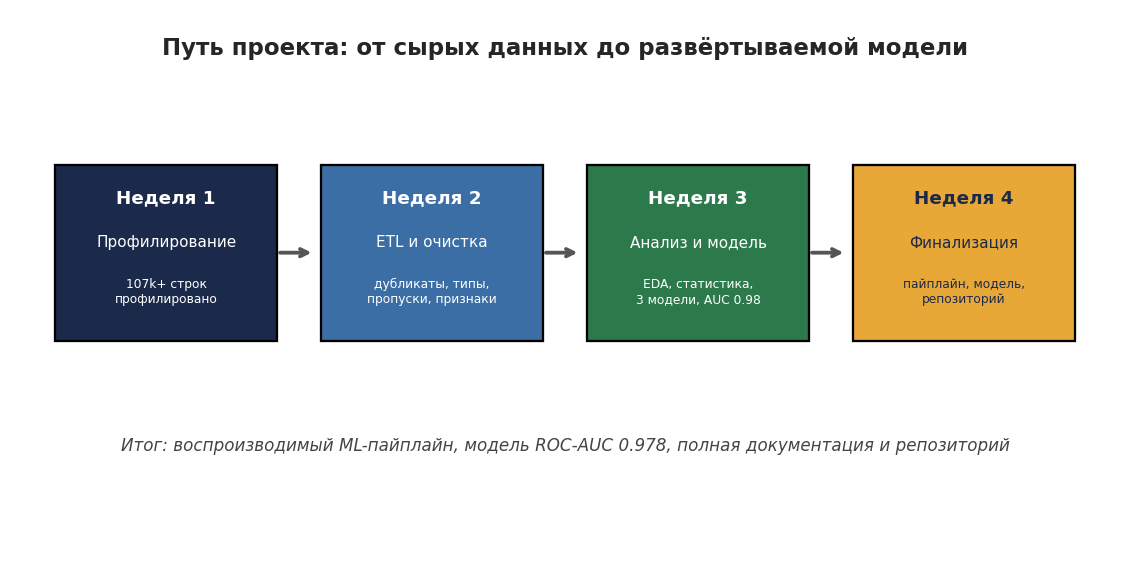

Сохранён график -> week4_project_summary.png


In [20]:
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.axis("off")

stages = [
    ("Неделя 1", "Профилирование", "107k+ строк\nпрофилировано", "#1B2A4A"),
    ("Неделя 2", "ETL и очистка", "дубликаты, типы,\nпропуски, признаки", "#3A6EA5"),
    ("Неделя 3", "Анализ и модель", "EDA, статистика,\n3 модели, AUC 0.98", "#2C7A4B"),
    ("Неделя 4", "Финализация", "пайплайн, модель,\nрепозиторий", "#E8A838"),
]

n = len(stages)
box_w = 0.20
gap = (1.0 - n * box_w) / (n + 1)

for i, (week, title, detail, color) in enumerate(stages):
    x = gap + i * (box_w + gap)
    # box
    ax.add_patch(plt.Rectangle((x, 0.4), box_w, 0.32, facecolor=color,
                                edgecolor="black", linewidth=1.5, transform=ax.transAxes))
    is_light = color == "#E8A838"
    txt_color = "#1B2A4A" if is_light else "white"
    ax.text(x + box_w/2, 0.66, week, ha="center", va="center", fontsize=12,
            fontweight="bold", color=txt_color, transform=ax.transAxes)
    ax.text(x + box_w/2, 0.58, title, ha="center", va="center", fontsize=10,
            color=txt_color, transform=ax.transAxes)
    ax.text(x + box_w/2, 0.49, detail, ha="center", va="center", fontsize=8,
            color=txt_color, transform=ax.transAxes)
    # arrow
    if i < n - 1:
        ax.annotate("", xy=(x + box_w + gap*0.85, 0.56), xytext=(x + box_w, 0.56),
                    xycoords=ax.transAxes,
                    arrowprops=dict(arrowstyle="->", lw=2.5, color="#555"))

ax.text(0.5, 0.92, "Путь проекта: от сырых данных до развёртываемой модели",
        ha="center", fontsize=15, fontweight="bold", transform=ax.transAxes)
ax.text(0.5, 0.2, f"Итог: воспроизводимый ML-пайплайн, модель ROC-AUC {test_auc:.3f}, "
        f"полная документация и репозиторий",
        ha="center", fontsize=11, style="italic", color="#444", transform=ax.transAxes)

plt.savefig("week4_project_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("Сохранён график -> week4_project_summary.png")

## 8. Итоги Недели 4

**Что выполнено**

1. Логика подготовки признаков собрана в переиспользуемый production-пайплайн `engineer_features`.
2. Обучена финальная модель на оптимальных гиперпараметрах и сохранена на диск (joblib).
3. Проведена 5-кратная кросс-валидация - модель стабильна (ROC-AUC 0.980 ± 0.002, без переобучения).
4. Продемонстрирован инференс: модель загружается из файла и предсказывает на новых данных.
5. Технические находки переведены в бизнес-выводы и практические рекомендации.
6. Собран репозиторий: README.md, requirements.txt, .gitignore, структура проекта.

**Файлы-результаты**

- `tender_model.joblib` - сохранённая обученная модель
- `README.md`, `requirements.txt`, `.gitignore` - файлы репозитория
- `week4_cv_stability.png`, `week4_project_summary.png` - графики

**Итог практики**

Реализован полный цикл анализа данных: профилирование (Неделя 1) -> ETL и очистка (Неделя 2) ->
анализ и моделирование (Неделя 3) -> финализация и документация (Неделя 4). Результат -
воспроизводимый пайплайн и развёртываемая модель с ROC-AUC ≈ 0.98, подкреплённая статистическим
анализом и оформленная как профессиональный репозиторий.
